# Neural ODE

In [11]:
# !pip install diffrax
# !pip install optax

In [12]:
import time
from datetime import datetime

import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax  # https://github.com/deepmind/optax
from optax.contrib import reduce_on_plateau as plateau

In [13]:
# MLP
class Func(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            # activation=jnn.tanh, # 결과가 더 안 좋음
            activation=jnn.softplus,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.mlp(y)

In [14]:
class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=0,
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

In [ ]:
def _get_data(ts, *, key):
    # Initial condition: (S0, I0)
    # y0 = jr.uniform(key, (2,), minval=0, maxval=100)
    y0 = jnp.array([100., 1.])

    def f(t, y, args):
        beta, alpha = args
        S, I = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - alpha * I
        return jnp.array([dSdt, dIdt])

    solver = diffrax.Tsit5()
    dt0 = 0.1
    beta = 0.025
    alpha = 0.2
    args = (beta, alpha)
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        (diffrax.ODETerm(f)), solver, 0, ts[-1], dt0, y0, args=args, saveat=saveat
    )
    ys = sol.ys
    return ys

# Returns ys with shape (dataset_size, len(ts), 2), where 2 represents the values for S and I.
def get_data(dataset_size, ts = None, *, key):
    # ts determines the dataset — specifically, it defines both the number and the distribution of the data.
    # ts = jnp.linspace(0, 30, 30)
    sampling = jnp.linspace(1.7, 7.8, 5)
    ts = jnp.concatenate([jnp.array([0.0]), sampling]) if ts is None else ts

    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, key=key))(key)
    return ts, ys

In [47]:
# Returns data of size dataset_size in the form of mini-batches. Note that we treat the 1,000 time points in ts as a single data sample.
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    assert dataset_size >= batch_size
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [48]:
def relative_error(pred, true):
    assert(pred.shape == true.shape)
    
    if pred.ndim == 0:  # Scalar case
        return jnp.abs(pred - true) / jnp.abs(true)
    else:  # Vector (or higher-dimension) case
        return jnp.linalg.norm(pred - true, 2) / jnp.linalg.norm(true, 2)
    
def get_experiment_id():
    return datetime.now().strftime("%Y%m%d%H%M%S%f")

In [49]:
def main(
    dataset_size=256,
    batch_size=32,
    lr=3e-3,
    steps_strategy=(500, 1000),
    length_strategy=(1, 1),
    width_size=64,
    depth=2,
    seed=5678,
    plot=True,
    print_every=100
):
    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    ts, ys = get_data(dataset_size, key=data_key)
    _, length_size, data_size = ys.shape

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    # optim = optax.adabelief(lr) provides better performance in general cases. 
    # When training a model to learn the initial conditions of S and I as parameters (while keeping the parameters in the differential equation fixed), it tends to perform better.
    optim = optax.adam(lr)
    # optim = optax.chain(
    #         optax.adam(lr),
    #         plateau(
    #             accumulation_size=5,
    #             patience=steps_strategy[0]//20
    #         )
    #     )   

    # Training loop like normal.
    #
    # Only thing to notice is that up until step 500 we train on only the first 10% of
    # each time series. This is a standard trick to avoid getting caught in a local
    # minimum.

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = jax.vmap(model, in_axes=(None, 0))(ti, yi[:, 0])
        return jnp.mean((yi - y_pred) ** 2)

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_list = []
    for steps, length in zip(steps_strategy, length_strategy):
        opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
        _ts = ts[: int(length_size * length)]
        _ys = ys[:, : int(length_size * length)]
        for step, (yi,) in zip(
            range(steps), dataloader((_ys,), batch_size, key=loader_key)
        ):
            start = time.time()
            loss, model, opt_state = make_step(_ts, yi, model, opt_state)
            loss_list.append(loss)
            end = time.time()
            if (step % print_every) == 0 or step == steps - 1:
                print(f"Step: {step}, Loss: {loss}, Computation time: {end - start}")

    if plot:
        exact_ts, exact_ys = get_data(1, ts=jnp.linspace(0, 30, 1000), key=data_key)
        model_y = model(exact_ts, exact_ys[0, 0])

        # relative error 계산
        rel_S = relative_error(exact_ys[0, :, 0], model_y[:, 0])
        rel_I = relative_error(exact_ys[0, :, 1], model_y[:, 1])

        # Figure setup
        figure = plt.figure(figsize=(15,5))
        plt.suptitle(f'Results - NeuralODE')

        # Subplot for Susceptible (S)
        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(exact_ts, exact_ys[0, :, 0], color='C0', label="Susceptible")
        ax1.plot(exact_ts, model_y[:, 0], linestyle='--', lw=2, color='C2', label='Trained NN')
        ax1.scatter(ts, ys[0, :, 0], color='red', marker='x', label='Sampled Susceptible', alpha=0.6)
        ax1.set_title(f'S(Relative error: {rel_S:.2e})')
        ax1.set_xlabel('t')
        ax1.legend()

        # Subplot for Infected (I)
        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(exact_ts, exact_ys[0, :, 1], color='C1', label="Infected")
        ax2.plot(exact_ts, model_y[:, 1], linestyle='--', lw=2, color='C3', label='Trained NN')
        ax2.scatter(ts, ys[0, :, 1], color='red', marker='x', label='Sampled Infected', alpha=0.6)
        ax2.set_title(f'I(Relative error: {rel_I:.2e})')
        ax2.set_xlabel('t')
        ax2.legend()

        # Subplot for Training Loss
        ax3 = figure.add_subplot(1,3,3)
        ax3.plot(loss_list, label='loss_total')
        ax3.set_yscale('log')  # y축을 로그 스케일로 변경
        # ax3.set_ylim(1e-6, 1e1)  # 적당한 범위로 설정 (필요하면 조정 가능)
        ax3.set_title('loss')
        ax3.set_xlabel('epoch')
        ax3.legend()

        plt.tight_layout()
        plt.savefig(f"result/neural_ode_{get_experiment_id()}.png")

    return ts, ys, model

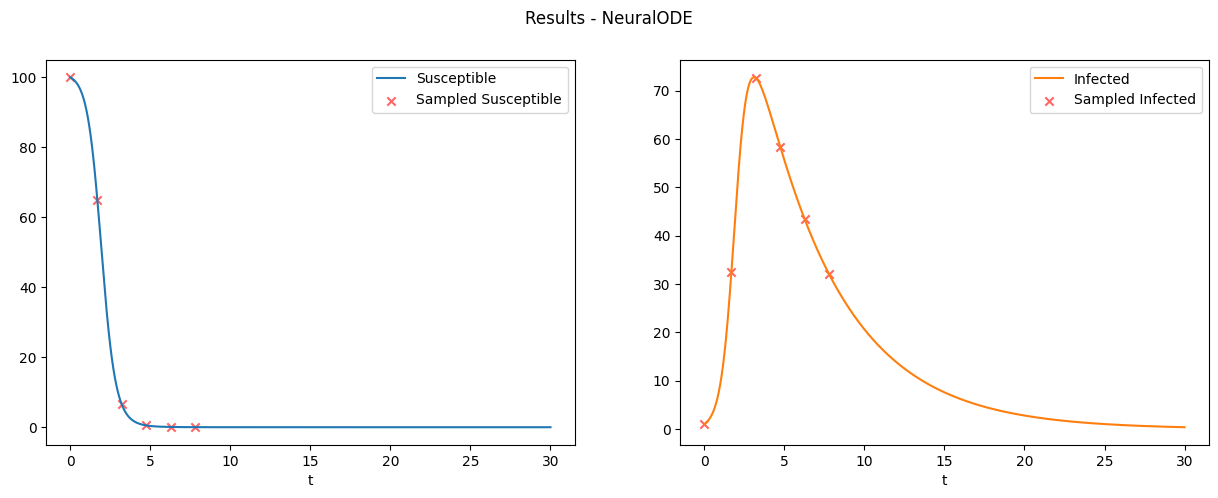

In [50]:
# sampling = jnp.linspace(0, 3, 5)
sampling = jnp.linspace(1.7, 7.8, 5)
sampling = jnp.concatenate([jnp.array([0.0]), sampling])

key = jr.PRNGKey(5678)
data_key, model_key, loader_key = jr.split(key, 3)
ts, ys = get_data(1, ts=sampling, key=data_key)

# Figure setup
figure = plt.figure(figsize=(15,5))
plt.suptitle(f'Results - NeuralODE')
exact_ts, exact_ys = get_data(1, ts=jnp.linspace(0, 30, 1000), key=data_key)

# Subplot for Susceptible (S)
ax1 = figure.add_subplot(1,2,1)
ax1.plot(exact_ts, exact_ys[0, :, 0], color='C0', label="Susceptible")
ax1.scatter(ts, ys[0, :, 0], color='red', marker='x', label='Sampled Susceptible', alpha=0.6)
ax1.set_xlabel('t')
ax1.legend()

# Subplot for Infected (I)
ax2 = figure.add_subplot(1,2,2)
ax2.plot(exact_ts, exact_ys[0, :, 1], color='C1', label="Infected")
ax2.scatter(ts, ys[0, :, 1], color='red', marker='x', label='Sampled Infected', alpha=0.6)
ax2.set_xlabel('t')
ax2.legend()

Step: 0, Loss: 3277.5126953125, Computation time: 4.194363594055176
Step: 100, Loss: 7.080066204071045, Computation time: 0.06334543228149414
Step: 200, Loss: 0.10371433943510056, Computation time: 0.07369041442871094
Step: 300, Loss: 0.015214978717267513, Computation time: 0.07238268852233887
Step: 400, Loss: 0.013794283382594585, Computation time: 0.07979941368103027
Step: 499, Loss: 0.012508274987339973, Computation time: 0.08800888061523438
Step: 0, Loss: 0.012496515177190304, Computation time: 0.06229877471923828
Step: 100, Loss: 0.034529779106378555, Computation time: 0.07313084602355957
Step: 200, Loss: 0.020386438816785812, Computation time: 0.0832376480102539
Step: 300, Loss: 0.020517056807875633, Computation time: 0.0661473274230957
Step: 400, Loss: 0.013380292803049088, Computation time: 0.05707263946533203
Step: 500, Loss: 0.012733316980302334, Computation time: 0.05433344841003418
Step: 600, Loss: 0.011992774903774261, Computation time: 0.0878305435180664
Step: 700, Loss: 

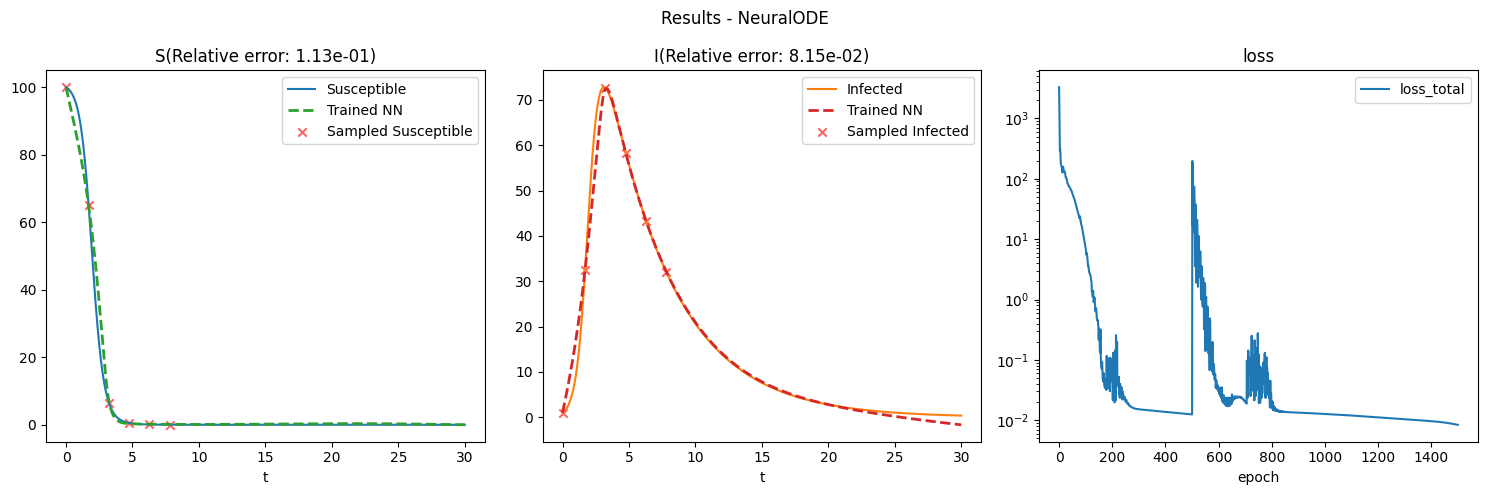

In [51]:
ts, ys, model = main()

Some notes on speed:
The hyperparameters for the above example haven't really been optimised. Try experimenting with them to see how much faster you can make this example run. There's lots of things you can try tweaking:

- The size of the neural network.
- The numerical solver.
- The step size controller, including both its step size and its tolerances.
- The length of the dataset. (Do you really need to use all of a time series every time?)
- Batch size, learning rate, choice of optimiser.
- ... etc.!

Some notes on being Markov:

- This example has assumed that the problem is Markov. Essentially, that the data `ys` is a complete observation of the system, and that we're not missing any channels. Note how the result of our model is evolving in data space. This is unlike e.g. an RNN, which has hidden state, and a linear map from hidden state to data.
- If we wanted we could generalise this to the non-Markov case: inside `NeuralODE`, project the initial condition into some high-dimensional latent space, do the ODE solve there, then take a linear map to get the output. See the [Latent ODE example](./latent_ode.ipynb) for an example doing this as part of a generative model; also see [Augmented Neural ODEs](https://arxiv.org/abs/1904.01681) for a short paper on it.